In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.observables import generate_edge_on_maps

/home/annalena/.conda/envs/phoenix/lib/python3.12/site-packages/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/.conda/envs/phoenix/lib/python3.12/site-packages/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax


# 1. SETUP PHYSICS PARAMETERS

In [2]:
# Potential parameters (Masses in M_sun, Distances in kpc)
pot_params = {
    'M_halo': 1e12, 'a_halo': 20.0,
    'M_disk': 5e10, 'a_disk': 3.0, 'b_disk': 0.3,
    'M_bulge': 1e10, 'a_bulge': 1.0
}

# Parameters for the Quasi-Isothermal Disk DF
disk_df_params = {
    "R0": 8.0, "Rd": 3.0, "Sigma0": 1000.0,
    "RsigR": 6.0, "RsigZ": 6.0,
    "sigmaR0_R0": 35.0, "sigmaz0_R0": 20.0,
    "L0": 10.0, "Rinit_for_Rc": 8.0
}

# Parameters for the Double Power-Law Spheroid DF
bulge_df_params = {
    "N0_spheroid": 1e10, "J0_spheroid": 100.0,
    "Gamma_spheroid": 1.5, "Beta_spheroid": 4.5, "eta_spheroid": 1.0
}

# 2. RUN THE OBSERVABLES PIPELINE

In [3]:
print("Initializing Phoenix Surrogate Mapper...")
mapper = PhoenixMapper()

print("\nGenerating soft-binned, fully differentiable kinematic maps...")
# We use fewer samples here (50k/25k) just to run the test quickly. 
# Feel free to bump these up to 100k+ for smoother maps!
maps = generate_edge_on_maps(
    mapper=mapper, 
    pot_params=pot_params, 
    disk_df_params=disk_df_params, 
    bulge_df_params=bulge_df_params,
    N_disk=50_000, 
    N_bulge=50_000,
    grid_size=40,      # Slightly higher resolution grid
    extent_x=15.0,     # View from -15 to +15 kpc
    extent_z=10.0,      # View from -5 to +5 kpc
    prng_seed=123
)

Initializing Phoenix Surrogate Mapper...
Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/.conda/envs/phoenix/lib/python3.12/site-packages/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/.conda/envs/phoenix/lib/python3.12/site-packages/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz
Model loaded and ready for inference!

Generating soft-binned, fully differentiable kinematic maps...


In [4]:
# Extract the outputs
mass_map = np.array(maps['mass'])
v_rot_map = np.array(maps['v_rot'])
sigma_map = np.array(maps['sigma'])
x_edges = np.array(maps['x_edges'])
z_edges = np.array(maps['z_edges'])
extent = [x_edges[0], x_edges[-1], z_edges[0], z_edges[-1]]

# 3. PLOTTING THE MAPS

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1824272/777194802.py:30: SyntaxWarning: invalid escape sequence '\s'
  axes[2].set_title('Line-of-Sight Velocity Dispersion ($\sigma_y$)')


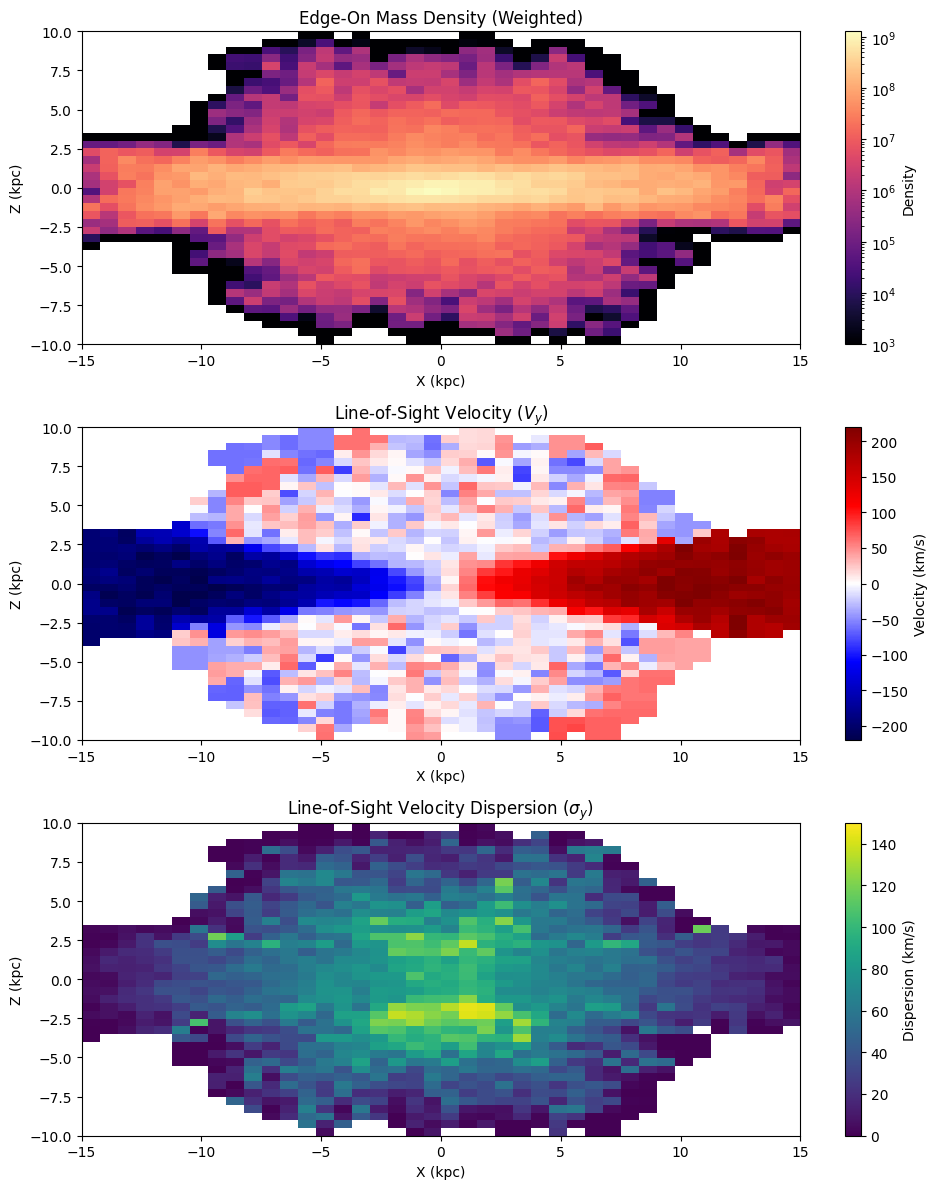

In [5]:
# To make the plots look clean, we mask out the pixels that have effectively zero mass
# (otherwise the background of the velocity maps will be plotted as 0.0)
mass_mask = mass_map > 1e-3
mass_plot = np.where(mass_mask, mass_map, np.nan)
vrot_plot = np.where(mass_mask, v_rot_map, np.nan)
sigma_plot = np.where(mass_mask, sigma_map, np.nan)

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
plt.subplots_adjust(hspace=0.3)

# 1. Mass Density Map
im0 = axes[0].imshow(mass_plot, origin='lower', extent=extent, 
                     cmap='magma', norm=LogNorm(vmin=1e3, vmax=np.nanmax(mass_plot)), aspect='auto')
axes[0].set_title('Edge-On Mass Density (Weighted)')
axes[0].set_xlabel('X (kpc)')
axes[0].set_ylabel('Z (kpc)')
fig.colorbar(im0, ax=axes[0], label='Density')

# 2. Line-of-Sight Velocity Map
im1 = axes[1].imshow(vrot_plot, origin='lower', extent=extent, 
                     cmap='seismic', vmin=-220, vmax=220, aspect='auto')
axes[1].set_title('Line-of-Sight Velocity ($V_y$)')
axes[1].set_xlabel('X (kpc)')
axes[1].set_ylabel('Z (kpc)')
fig.colorbar(im1, ax=axes[1], label='Velocity (km/s)')

# 3. Velocity Dispersion Map
im2 = axes[2].imshow(sigma_plot, origin='lower', extent=extent, 
                     cmap='viridis', vmin=0, vmax=150, aspect='auto')
axes[2].set_title('Line-of-Sight Velocity Dispersion ($\sigma_y$)')
axes[2].set_xlabel('X (kpc)')
axes[2].set_ylabel('Z (kpc)')
fig.colorbar(im2, ax=axes[2], label='Dispersion (km/s)')

plt.tight_layout()
plt.show()